In [9]:
%load_ext autoreload
%autoreload 2

In [1]:
# fix python path if working locally
from utils import fix_pythonpath_if_working_locally

fix_pythonpath_if_working_locally()
%matplotlib inline

In [ ]:
import warnings

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import MissingValuesFiller, Scaler
from darts.datasets import EnergyDataset
from darts.metrics import ae, r2_score
from darts.models.forecasting.xlstm_mixer import xLSTMMixer

(976, 1, 1)

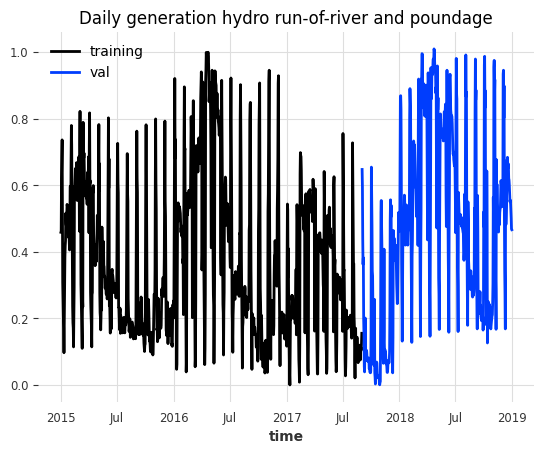

In [3]:
df = EnergyDataset().load().pd_dataframe()
df_day_avg = df.groupby(df.index.astype(str).str.split(" ").str[0]).mean().reset_index()
filler = MissingValuesFiller()
scaler = Scaler()
series = filler.transform(
    TimeSeries.from_dataframe(
        df_day_avg, "time", ["generation hydro run-of-river and poundage"]
    )
).astype(np.float32)

train, val = series.split_after(pd.Timestamp("20170901"))

train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
series_scaled = scaler.transform(series)


train_scaled.plot(label="training")
val_scaled.plot(label="val")
plt.title("Daily generation hydro run-of-river and poundage")
train_scaled.shape

In [63]:
from darts.utils.likelihood_models import GaussianLikelihood

model = xLSTMMixer(30, 7, likelihood=GaussianLikelihood())
model.fit(train_scaled, verbose=True, epochs=10)

Training: |          | 0/? [00:00<?, ?it/s]

xLSTMMixer(input_chunk_length=30, output_chunk_length=7, output_chunk_shift=0, xlstm_embedding_dim=256, num_mem_tokens=12, num_tokens_per_variate=1, xlstm_dropout=0, xlstm_conv1d_kernel_size=2, xlstm_num_heads=2, xlstm_num_blocks=4, use_mlstm=False, use_reversible_instance_norm=True, packing=1, backbone=nlinear, likelihood=GaussianLikelihood(prior_mu=None, prior_sigma=None, prior_strength=1.0, beta_nll=0.0))

In [64]:
pred_series = model.historical_forecasts(
    series_scaled,
    start=val.start_time(),
    forecast_horizon=7,
    stride=7,
    last_points_only=False,
    retrain=False,
    verbose=True,
)
pred_series = concatenate(pred_series)

Predicting: |          | 0/? [00:00<?, ?it/s]

In [65]:
def display_forecast(pred_series, ts_transformed, forecast_type, start_date=None):
    plt.figure(figsize=(8, 5))
    if start_date:
        ts_transformed = ts_transformed.drop_before(start_date)
    ts_transformed.univariate_component(0).plot(label="actual")
    pred_series.plot(label=("historic " + forecast_type + " forecasts"))
    plt.title(f"R2: {r2_score(ts_transformed.univariate_component(0), pred_series)}")
    plt.legend()

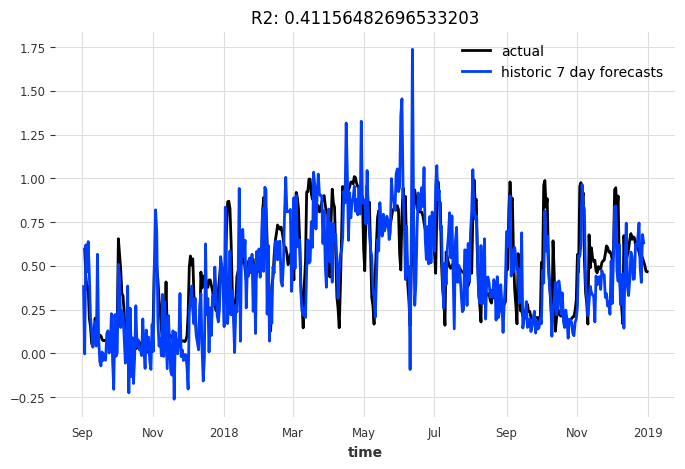

In [66]:
display_forecast(
    pred_series,
    series_scaled,
    "7 day",
    start_date=val.start_time(),
)

In [67]:
np.mean(ae(series_scaled, pred_series))

0.15912265